# DiFrauD under scarce positive labels
## A leakage-resistant nnPU and Mean Teacher study of domain-independent deception detection

**Abstract.** This executable study asks whether textual deception transfers across seven heterogeneous domains when only a small fraction of deceptive training examples is labeled. It combines the non-negative positive–unlabeled (nnPU) risk estimator with a confidence-filtered exponential-moving-average teacher. Alongside leakage-resistant in-domain and leave-one-domain-out (LODO) evaluation, it audits composition, integrity, duplication, source shortcuts, label ambiguity, and distribution shift. Quick mode is a real, CPU-oriented representative experiment; full mode expands seeds, samples, and held-out domains. Results are not claims of factual verification or intent.

**Research questions.** Can deception be detected across heterogeneous domains? What remains with 1%, 5%, 10%, or 20% labeled positives? Does nnPU beat pseudo-negative training? Does consistency help? Does the model learn deception or dataset provenance? Does it transfer to an unseen domain?

**Proposed method.** The *PU–Mean Teacher Deception Detector* trains a student on valid nnPU classification risk and consistency against a confidence-filtered EMA teacher. Unlabeled examples are never declared negative.

## 1. Environment and reproducibility

In [1]:
from pathlib import Path
import os, re, random, platform, importlib.metadata as im, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
get_ipython().run_line_magic("matplotlib", "inline")
from scipy.spatial.distance import jensenshannon
from scipy.stats import bootstrap
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
    f1_score, average_precision_score)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import torch
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

from src.data_utils import (DOMAINS, add_text_features, exact_leakage_table,
    load_difraud, make_pu_partition, training_view)
from src.pu_loss import nnpu_loss
from src.models import (MLPClassifier, consistency_loss, ema_update,
    make_teacher, mask_embedding, sigmoid_rampup)
from src.evaluation import choose_threshold, classification_metrics

MODE = os.environ.get("DIFRAUD_MODE", "quick")
CONFIG = {
    "mode": MODE, "seed": 42,
    "domains": list(DOMAINS), "positive_fractions": [0.01, 0.05, 0.10, 0.20],
    "seeds": [42] if MODE == "quick" else [42, 73, 101],
    "batch_size": 128 if MODE == "quick" else 64,
    "epochs": 6 if MODE == "quick" else 20,
    "learning_rate": 2e-3 if MODE == "quick" else 2e-5,
    "confidence_threshold": 0.80, "ema_decay": 0.99,
    "max_text_length": 256,
    "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
    "sample_per_domain_split": 500 if MODE == "quick" else None,
    "lodo_domains": ["job_scams", "product_reviews", "phishing"] if MODE == "quick" else list(DOMAINS),
    "output_dir": "outputs", "data_dir": "data/raw",
}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Path(CONFIG["output_dir"]).mkdir(parents=True, exist_ok=True)
Path(CONFIG["data_dir"]).mkdir(parents=True, exist_ok=True)

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)

seed_everything(CONFIG["seed"])
versions = {p: im.version(p) for p in ["numpy", "pandas", "scikit-learn", "torch",
    "sentence-transformers", "huggingface-hub"]}
print({"python": platform.python_version(), "device": str(DEVICE), **versions})
print(CONFIG)

{'python': '3.12.13', 'device': 'cpu', 'numpy': '2.5.1', 'pandas': '3.0.5', 'scikit-learn': '1.9.0', 'torch': '2.13.0', 'sentence-transformers': '5.6.1', 'huggingface-hub': '1.26.0'}
{'mode': 'quick', 'seed': 42, 'domains': ['phishing', 'fake_news', 'political_statements', 'product_reviews', 'job_scams', 'sms', 'twitter_rumours'], 'positive_fractions': [0.01, 0.05, 0.1, 0.2], 'seeds': [42], 'batch_size': 128, 'epochs': 6, 'learning_rate': 0.002, 'confidence_threshold': 0.8, 'ema_decay': 0.99, 'max_text_length': 256, 'embedding_model': 'sentence-transformers/all-MiniLM-L6-v2', 'sample_per_domain_split': 500, 'lodo_domains': ['job_scams', 'product_reviews', 'phishing'], 'output_dir': 'outputs', 'data_dir': 'data/raw'}


## 2. Official dataset acquisition and validation

The loader queries the Hub file manifest and downloads the official JSON/JSONL files at an immutable commit SHA. It deliberately does **not** execute the repository loading script or enable arbitrary remote code. Each official split is retained. Quick mode makes a label-stratified cap *within each domain/split* after validation; it does not invent new splits.

In [2]:
raw, DATASET_REVISION = load_difraud(CONFIG["data_dir"])
print("DiFrauD revision:", DATASET_REVISION)
validation = pd.Series({
    "rows": len(raw), "missing_text": int(raw.text.isna().sum()),
    "empty_text": int(raw.text.fillna("").str.strip().eq("").sum()),
    "missing_label": int(raw.label.isna().sum()),
    "invalid_labels": int((~raw.label.isin([0, 1])).sum()),
    "domains": raw.domain.nunique(), "splits": raw.split.nunique(),
    "source_files": raw.source_file.nunique(),
})
display(validation.to_frame("value"))
summary_full = raw.groupby(["domain", "split", "label"]).size().unstack(fill_value=0)
summary_full.columns = ["non_deceptive", "deceptive"]
summary_full["total"] = summary_full.sum(axis=1)
summary_full["positive_prevalence"] = summary_full.deceptive / summary_full.total
display(summary_full)

def stratified_cap(group, cap, seed=42):
    if cap is None or len(group) <= cap: return group
    pieces = []
    for _, part in group.groupby("label"):
        n = max(1, round(cap * len(part) / len(group)))
        pieces.append(part.sample(min(n, len(part)), random_state=seed))
    return pd.concat(pieces).sample(frac=1, random_state=seed).head(cap)

data = (raw.groupby(["domain", "split"], group_keys=False)
        .apply(lambda g: stratified_cap(g, CONFIG["sample_per_domain_split"]), include_groups=False)
        .reset_index(drop=True))
# pandas include_groups=False removes grouping columns; restore safely from retained source path.
if "domain" not in data:
    data = pd.concat([stratified_cap(g, CONFIG["sample_per_domain_split"])
        for _, g in raw.groupby(["domain", "split"], sort=False)], ignore_index=True)
data = add_text_features(data)
print(f"Analysis rows: {len(data):,} (full official rows: {len(raw):,})")

DiFrauD revision: aaaf94b336c563a14806bb4f3f58727bed9ed8d4


,value
rows,95854
missing_text,0
empty_text,0
missing_label,0
invalid_labels,0
domains,7
splits,3
source_files,21


non_deceptive  deceptive  total  \
domain               split                                         
fake_news            test                 1163        883   2046   
                     train                9299       7065  16364   
                     validation           1162        884   2046   
job_scams            test                 1370         60   1430   
                     train               10957        479  11436   
                     validation           1369         60   1429   
phishing             test                  920        608   1528   
                     train                7358       4859  12217   
                     validation            920        607   1527   
political_statements test                  445        805   1250   
                     train                3564       6433   9997   
                     validation            446        804   1250   
product_reviews      test                 1048       1050   2098   
                     train                8383       8393  16776   
                     validation           1048       1049   2097   
sms                  test                  530        128    658   
                     train                4240       1019   5259   
                     validation            530        127    657   
twitter_rumours      test                  382        197    579   
                     train                3056       1575   4631   
                     validation            382        197    579   

                                 positive_prevalence  
domain               split                            
fake_news            test                   0.431574  
                     train                  0.431740  
                     validation             0.432063  
job_scams            test                   0.041958  
                     train                  0.041885  
                     validation             0.041987  
phishing             test                   0.397906  
                     train                  0.397724  
                     validation             0.397511  
political_statements test                   0.644000  
                     train                  0.643493  
                     validation             0.643200  
product_reviews      test                   0.500477  
                     train                  0.500298  
                     validation             0.500238  
sms                  test                   0.194529  
                     train                  0.193763  
                     validation             0.193303  
twitter_rumours      test                   0.340242  
                     train                  0.340099  
                     validation             0.340242

Analysis rows: 10,500 (full official rows: 95,854)


## 3. Creative dataset-quality audit

### 3.1 Composition, imbalance, and text integrity

Wilson 95% intervals describe domain/split prevalence uncertainty. Integrity features target parsing and source artifacts: length, sentences, URLs, digits, punctuation, capitalization, non-ASCII text, repeated punctuation, HTML residue, and replacement characters. Outliers use the robust 1.5×IQR rule within domains.

n  positives  prevalence  \
domain               split                                    
fake_news            test        500        216       0.432   
                     train       500        216       0.432   
                     validation  500        216       0.432   
job_scams            test        500         21       0.042   
                     train       500         21       0.042   
                     validation  500         21       0.042   
phishing             test        500        199       0.398   
                     train       500        199       0.398   
                     validation  500        199       0.398   
political_statements test        500        322       0.644   
                     train       500        322       0.644   
                     validation  500        322       0.644   
product_reviews      test        500        250       0.500   
                     train       500        250       0.500   
                     validation  500        250       0.500   
sms                  test        500         97       0.194   
                     train       500         97       0.194   
                     validation  500         97       0.194   
twitter_rumours      test        500        170       0.340   
                     train       500        170       0.340   
                     validation  500        170       0.340   

                                 prevalence_ci_low  prevalence_ci_high  \
domain               split                                               
fake_news            test                    0.389               0.476   
                     train                   0.389               0.476   
                     validation              0.389               0.476   
job_scams            test                    0.028               0.063   
                     train                   0.028               0.063   
                     validation              0.028               0.063   
phishing             test                    0.356               0.442   
                     train                   0.356               0.442   
                     validation              0.356               0.442   
political_statements test                    0.601               0.685   
                     train                   0.601               0.685   
                     validation              0.601               0.685   
product_reviews      test                    0.456               0.544   
                     train                   0.456               0.544   
                     validation              0.456               0.544   
sms                  test                    0.162               0.231   
                     train                   0.162               0.231   
                     validation              0.162               0.231   
twitter_rumours      test                    0.300               0.383   
                     train                   0.300               0.383   
                     validation              0.300               0.383   

                                 imbalance_ratio_majority_to_minority  
domain               split                                             
fake_news            test                                       1.315  
                     train                                      1.315  
                     validation                                 1.315  
job_scams            test                                      22.810  
                     train                                     22.810  
                     validation                                22.810  
phishing             test                                       1.513  
                     train                                      1.513  
                     validation                                 1.513  
political_statements test                                       1.809  
                  

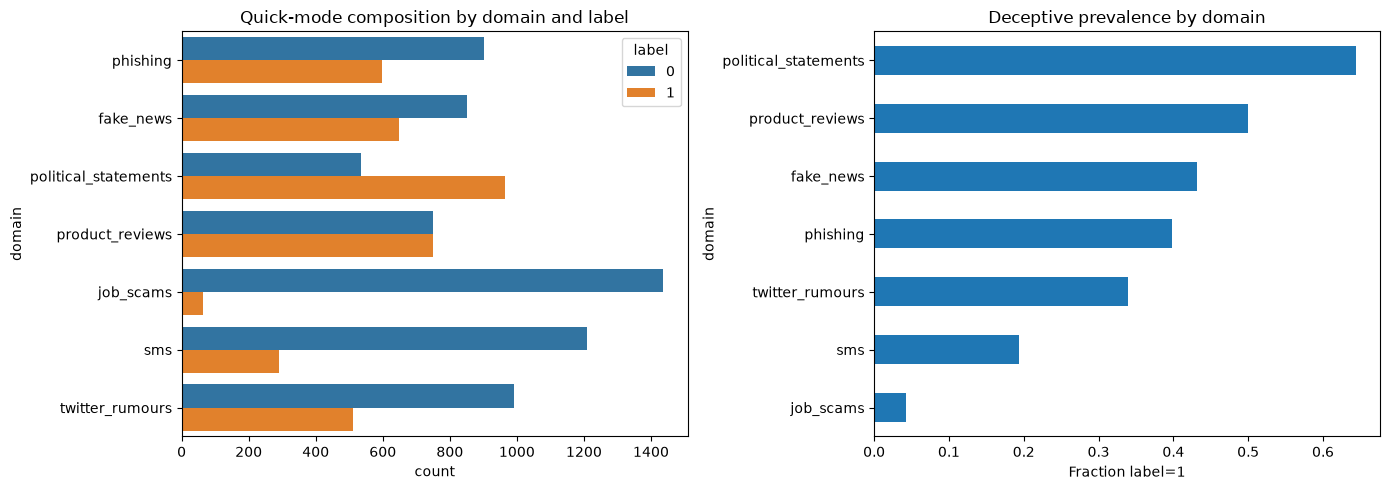

,char_count,word_count,sentence_count,url_count,digit_count,punctuation_count,uppercase_ratio,non_ascii_count,repeated_punctuation,html_residue,replacement_chars
domain,,,,,,,,,,,
fake_news,2475.0,420.5,21.0,0.0,12.0,60.0,0.04,0.0,0.0,0.0,0.0
job_scams,1042.5,161.0,7.0,0.0,1.0,23.0,0.03,0.0,0.0,0.0,0.0
phishing,1056.0,176.5,12.0,0.0,20.0,44.0,0.07,0.0,0.0,0.0,0.0
political_statements,99.0,17.0,1.0,0.0,0.0,2.0,0.04,0.0,0.0,0.0,0.0
product_reviews,231.0,45.0,4.0,0.0,0.0,6.0,0.03,0.0,0.0,0.0,0.0
sms,67.0,13.0,2.0,0.0,0.0,3.0,0.05,0.0,0.0,0.0,0.0
twitter_rumours,126.0,20.0,2.0,1.0,2.0,8.0,0.11,0.0,0.0,0.0,0.0


{'empty': 0, 'extremely_short_le_3_words': 33, 'length_outliers': 471, 'html_rows': 69, 'encoding_replacement_rows': 147}


In [3]:
from statsmodels.stats.proportion import proportion_confint
audit = data.groupby(["domain", "split"]).agg(n=("label","size"), positives=("label","sum"))
audit["prevalence"] = audit.positives / audit.n
ci = [proportion_confint(k, n, method="wilson") for k,n in zip(audit.positives,audit.n)]
audit[["prevalence_ci_low","prevalence_ci_high"]] = ci
audit["imbalance_ratio_majority_to_minority"] = audit[["positives","n"]].apply(
    lambda r: max(r.positives, r.n-r.positives) / max(1, min(r.positives, r.n-r.positives)), axis=1)
display(audit.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=data, y="domain", hue="label", ax=axes[0]); axes[0].set_title("Quick-mode composition by domain and label")
prev = data.groupby("domain").label.mean().sort_values()
prev.plot.barh(ax=axes[1]); axes[1].set_title("Deceptive prevalence by domain"); axes[1].set_xlabel("Fraction label=1")
plt.tight_layout(); plt.show()

integrity_cols = ["char_count","word_count","sentence_count","url_count","digit_count",
                  "punctuation_count","uppercase_ratio","non_ascii_count","repeated_punctuation",
                  "html_residue","replacement_chars"]
display(data.groupby("domain")[integrity_cols].median().round(2))
q1, q3 = data.groupby("domain").char_count.transform("quantile", .25), data.groupby("domain").char_count.transform("quantile", .75)
extreme = data.char_count > q3 + 1.5*(q3-q1)
print({"empty": int(data.normalized_text.eq("").sum()), "extremely_short_le_3_words": int((data.word_count<=3).sum()),
       "length_outliers": int(extreme.sum()), "html_rows": int((data.html_residue>0).sum()),
       "encoding_replacement_rows": int((data.replacement_chars>0).sum())})

### 3.2 Exact duplicates, conflicting labels, and near-duplicate split leakage

Exact normalized hashes are exhaustive. Near-duplicate search uses character 3–5 gram TF–IDF and cosine neighbors on the quick sample; only cross-split pairs above 0.92 are counted. Text excerpts are truncated to 120 characters to limit disclosure.

In [4]:
dupes = exact_leakage_table(data)
display(pd.Series({"duplicate_groups": len(dupes),
    "cross_domain_groups": int((dupes.domains>1).sum()) if len(dupes) else 0,
    "cross_split_groups": int((dupes.splits>1).sum()) if len(dupes) else 0,
    "conflicting_label_groups": int(dupes.conflicting_labels.sum()) if len(dupes) else 0}).to_frame("count"))

char_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5), min_df=2, max_features=30000)
X_char = char_vec.fit_transform(data.normalized_text)
nn = NearestNeighbors(n_neighbors=2, metric="cosine", n_jobs=-1).fit(X_char)
dist, idx = nn.kneighbors(X_char)
pairs = pd.DataFrame({"i":np.arange(len(data)), "j":idx[:,1], "similarity":1-dist[:,1]})
pairs = pairs[(pairs.i < pairs.j) & (pairs.similarity >= .92)]
pairs["cross_split"] = [data.iloc[i].split != data.iloc[j].split for i,j in zip(pairs.i,pairs.j)]
print({"near_duplicate_pairs_ge_0.92":len(pairs), "cross_split_near_pairs":int(pairs.cross_split.sum())})
examples=[]
for _,r in pairs[pairs.cross_split].head(5).iterrows():
    a,b=data.iloc[int(r.i)],data.iloc[int(r.j)]
    examples.append({"similarity":r.similarity,"a":a.text[:120],"a_split":a.split,"b":b.text[:120],"b_split":b.split})
display(pd.DataFrame(examples))

,count
duplicate_groups,0
cross_domain_groups,0
cross_split_groups,0
conflicting_label_groups,0


{'near_duplicate_pairs_ge_0.92': 296, 'cross_split_near_pairs': 212}


,similarity,a,a_split,b,b_split
0,0.943292,Your Wamu.com Account Verification Process ygu...,train,Your Wamu.com Account Verification Process vtk...,validation
1,0.961266,"China's rapid economic growth, as ranked by th...",train,==============================================...,test
2,0.952376,eBay sent this message to eBay Member.Your reg...,train,eBay sent this message to you. Question about ...,validation
3,0.964964,Will get right back Just pinged our EP Savanna...,train,"Hi Savannah, it was great seeing you Saturday....",test
4,0.971455,You have added johny26@cox.com as a new email ...,train,You've added an additional email address to yo...,validation


### 3.3 Shortcut learning, domain separability, and suspected label issues

The domain-prior baseline uses training-domain prevalence only. The metadata model uses no text. A domain classifier and SVD map quantify provenance signal. Label-quality screening uses leakage-safe out-of-fold text predictions on training rows; disagreement indicates ambiguity or shortcut failure—not a confirmed error.

Metadata-only {'precision': 0.43141852286049237, 'recall': 0.8658823529411764, 'f1': 0.5758998435054773, 'macro_f1': 0.5311590184046654, 'balanced_accuracy': 0.6059748843357567, 'roc_auc': 0.6546449878827936, 'pr_auc': 0.48296530779378355, 'mcc': 0.23005045273675293, 'brier': 0.24098267411858176, 'ece': 0.13467087919503085, 'recall_at_90_precision': 0.001568627450980392, 'precision_at_5pct_alert_budget': 0.56, 'false_positives_per_1000_negatives': np.float64(653.9325842696629), 'tn': 770, 'fp': 1455, 'fn': 171, 'tp': 1104}
Domain-prior {'precision': 0.4628, 'recall': 0.9074509803921569, 'f1': 0.6129801324503311, 'macro_f1': 0.5799784383181887, 'balanced_accuracy': 0.6519277373870896, 'roc_auc': 0.7211940956157744, 'pr_auc': 0.5403282352941177, 'mcc': 0.32368096592499385, 'brier': 0.19789085714285715, 'ece': 1.586032892321652e-17, 'recall_at_90_precision': 0.0, 'precision_at_5pct_alert_budget': 0.644, 'false_positives_per_1000_negatives': np.float64(603.5955056179776), 'tn': 882, 'fp': 

Domain classifier accuracy: 0.9308571428571428


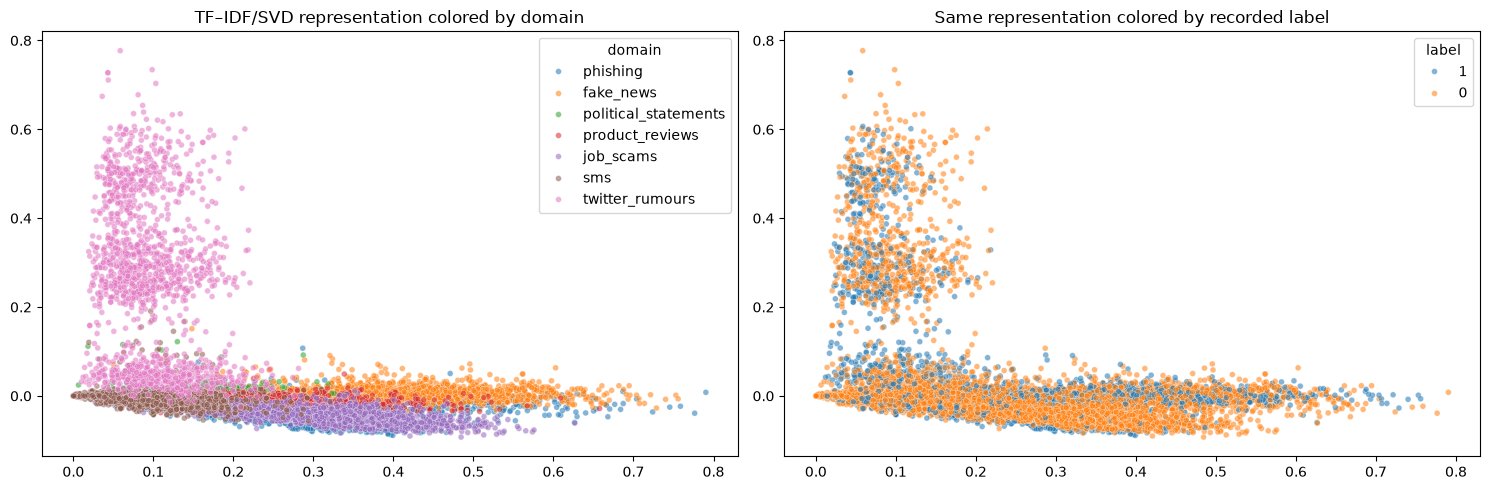

,domain,label,oof_probability,text
2342,job_scams,1,0.066896,"Position :Manager, Software Development Job Ty..."
2020,job_scams,1,0.097638,Do you want to help improve the lives of farme...
3136,twitter_rumours,0,0.847080,#SydneySiege - 5 people injured - Reports of a...
2404,job_scams,1,0.156559,The company is seeking an Admin assistant to j...
2172,job_scams,1,0.157619,Corporate overview Aker Solutions is a global ...
2142,job_scams,1,0.159091,Apply using below link We are currently seekin...
2448,job_scams,1,0.161635,Corporate overview Aker Solutions is a global ...
2856,sms,0,0.819396,Whens your radio show?


In [5]:
train = data[data.split=="train"].reset_index(drop=True)
val = data[data.split=="validation"].reset_index(drop=True)
test = data[data.split=="test"].reset_index(drop=True)
metadata_cols = ["char_count","word_count","sentence_count","url_count","digit_count",
                 "punctuation_count","uppercase_ratio","non_ascii_count","repeated_punctuation","html_residue"]
meta_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced"))
meta_model.fit(train[metadata_cols], train.label)
meta_p = meta_model.predict_proba(test[metadata_cols])[:,1]
domain_prior = train.groupby("domain").label.mean()
prior_p = test.domain.map(domain_prior).fillna(train.label.mean()).to_numpy()
print("Metadata-only", classification_metrics(test.label, meta_p, choose_threshold(val.label, meta_model.predict_proba(val[metadata_cols])[:,1])))
print("Domain-prior", classification_metrics(test.label, prior_p, choose_threshold(val.label, val.domain.map(domain_prior).fillna(train.label.mean()))))

tfidf_domain = TfidfVectorizer(min_df=3, max_features=15000, ngram_range=(1,2), sublinear_tf=True)
Xd = tfidf_domain.fit_transform(train.text.fillna("")); Xdt = tfidf_domain.transform(test.text.fillna(""))
domain_clf = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xd, train.domain)
print("Domain classifier accuracy:", domain_clf.score(Xdt, test.domain))
svd = TruncatedSVD(n_components=2, random_state=CONFIG["seed"])
coords = svd.fit_transform(TfidfVectorizer(min_df=3,max_features=15000).fit_transform(data.text.fillna("")))
fig,axes=plt.subplots(1,2,figsize=(15,5))
sns.scatterplot(x=coords[:,0],y=coords[:,1],hue=data.domain,alpha=.55,s=18,ax=axes[0]); axes[0].set_title("TF–IDF/SVD representation colored by domain")
sns.scatterplot(x=coords[:,0],y=coords[:,1],hue=data.label.astype(str),alpha=.55,s=18,ax=axes[1]); axes[1].set_title("Same representation colored by recorded label")
plt.tight_layout(); plt.show()

oof_pipe = make_pipeline(TfidfVectorizer(min_df=3,max_features=20000,ngram_range=(1,2)),
                         LogisticRegression(max_iter=1000,class_weight="balanced"))
cv = StratifiedKFold(5, shuffle=True, random_state=CONFIG["seed"])
oof = cross_val_predict(oof_pipe, train.text.fillna(""), train.label, cv=cv, method="predict_proba", n_jobs=-1)[:,1]
suspect = train.assign(oof_probability=oof, disagreement=np.where(train.label.eq(1),1-oof,oof))
display(suspect.nlargest(8,"disagreement")[["domain","label","oof_probability","text"]].assign(text=lambda x:x.text.str[:160]))

### 3.4 Distribution shift and quality scorecard

Pairwise Jensen–Shannon distance compares smoothed domain unigram distributions (0=same, 1=maximally separated with base 2). Vocabulary overlap is Jaccard overlap among each domain's 1,000 most frequent terms. The scorecard intentionally avoids an arbitrary overall score.

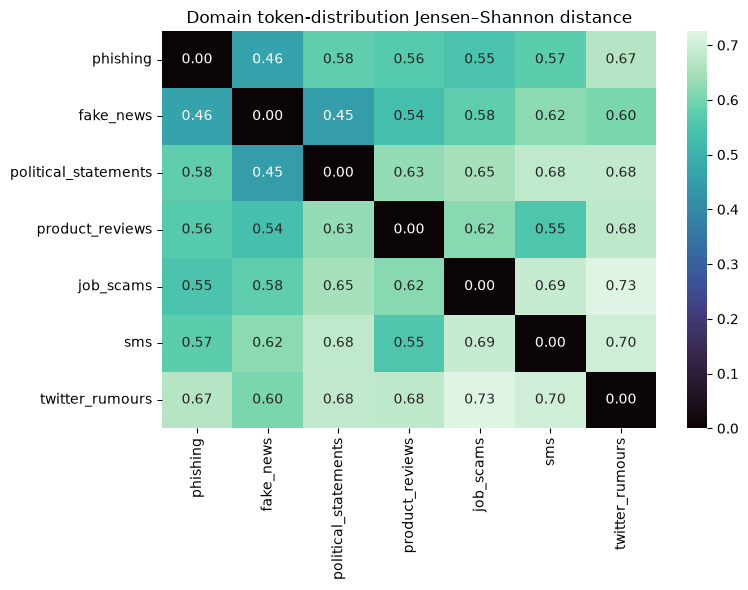

,phishing,fake_news,political_statements,product_reviews,job_scams,sms,twitter_rumours
phishing,1.00,0.37,0.28,0.25,0.26,0.28,0.25
fake_news,0.37,1.00,0.40,0.28,0.23,0.27,0.36
political_statements,0.28,0.40,1.00,0.21,0.19,0.21,0.23
product_reviews,0.25,0.28,0.21,1.00,0.21,0.31,0.23
job_scams,0.26,0.23,0.19,0.21,1.00,0.18,0.17
sms,0.28,0.27,0.21,0.31,0.18,1.00,0.24
twitter_rumours,0.25,0.36,0.23,0.23,0.17,0.24,1.00


,dimension,evidence,interpretation
0,Completeness,0 missing; 0 empty,quantitative
1,Uniqueness,0 duplicate normalized-text groups,risk flag
2,Label consistency,0 conflicting duplicate groups,risk flag
3,Leakage risk,0 exact cross-split groups; 212 sampled near p...,risk flag
4,Class balance,domain prevalence range 0.04–0.64,domain-dependent
5,Domain shift,mean off-diagonal JS distance 0.61,substantial if high
6,Representativeness,Seven heterogeneous English source domains; no...,limited
7,Documentation,Dataset card plus constituent provenance; audi...,review needed
8,Reproducibility,"Hub SHA aaaf94b336c5, official splits, seeded ...",strong


In [6]:
v = TfidfVectorizer(max_features=10000, use_idf=False, norm="l1", binary=False)
M = v.fit_transform(data.text.fillna("")); domains=list(DOMAINS)
means={d:np.asarray(M[data.domain.eq(d).to_numpy()].mean(axis=0)).ravel()+1e-12 for d in domains}
js=pd.DataFrame(index=domains,columns=domains,dtype=float)
for a in domains:
    for b in domains: js.loc[a,b]=jensenshannon(means[a],means[b],base=2)
plt.figure(figsize=(8,6)); sns.heatmap(js,annot=True,fmt=".2f",cmap="mako"); plt.title("Domain token-distribution Jensen–Shannon distance"); plt.tight_layout(); plt.show()

top={d:set(np.argsort(means[d])[-1000:]) for d in domains}
jacc=pd.DataFrame([[len(top[a]&top[b])/len(top[a]|top[b]) for b in domains] for a in domains],index=domains,columns=domains)
display(jacc.round(2))
scorecard=pd.DataFrame({
 "dimension":["Completeness","Uniqueness","Label consistency","Leakage risk","Class balance","Domain shift","Representativeness","Documentation","Reproducibility"],
 "evidence":[f"{validation.missing_text} missing; {validation.empty_text} empty",f"{len(dupes)} duplicate normalized-text groups",
             f"{int(dupes.conflicting_labels.sum()) if len(dupes) else 0} conflicting duplicate groups",
             f"{int((dupes.splits>1).sum()) if len(dupes) else 0} exact cross-split groups; {int(pairs.cross_split.sum())} sampled near pairs",
             f"domain prevalence range {data.groupby('domain').label.mean().min():.2f}–{data.groupby('domain').label.mean().max():.2f}",
             f"mean off-diagonal JS distance {js.values[np.triu_indices(7,1)].mean():.2f}",
             "Seven heterogeneous English source domains; not population representative",
             "Dataset card plus constituent provenance; audit original sources before deployment",
             f"Hub SHA {DATASET_REVISION[:12]}, official splits, seeded execution"],
 "interpretation":["quantitative","risk flag","risk flag","risk flag","domain-dependent","substantial if high","limited","review needed","strong"]})
display(scorecard)

## 4. Leakage-safe design, baselines, and PU protocol

**Setting A (in-domain):** train only on official training data, select thresholds on official validation data, and evaluate official test once. **Setting B (LODO):** remove an entire domain before any training or prior estimate; select thresholds on validation rows from remaining domains; the held-out domain's labels are used only for final scoring.

For each labeled-positive fraction, a seeded subset of positive training examples becomes `P`; all negatives and remaining positives become `U`. The training view removes both recorded and hidden labels. Oracle prevalence is a non-deployable reference. A deployable Elkan–Noto estimate is computed from training-only out-of-fold probabilities as `mean(s(x)|P)` and clipped for stability. Sensitivity uses 0.75π, π, and 1.25π.

The naive U-as-negative baseline is included explicitly as an invalid PU comparator—not called PU learning. Majority, domain-prior, metadata, supervised TF–IDF/logistic regression, and fully supervised neural classifiers provide anchors.

In [7]:
text_model = make_pipeline(TfidfVectorizer(min_df=3,max_features=30000,ngram_range=(1,2),sublinear_tf=True),
                           LogisticRegression(max_iter=1500,class_weight="balanced"))
text_model.fit(train.text.fillna(""),train.label)
val_text_p=text_model.predict_proba(val.text.fillna(""))[:,1]
test_text_p=text_model.predict_proba(test.text.fillna(""))[:,1]
thr=choose_threshold(val.label,val_text_p)
baseline_rows=[{"method":"majority","fraction":1.0,**classification_metrics(test.label,np.full(len(test),train.label.mean()),.5)},
               {"method":"supervised_tfidf_upper_bound","fraction":1.0,**classification_metrics(test.label,test_text_p,thr)}]
print(pd.DataFrame(baseline_rows)[["method","f1","macro_f1","pr_auc","roc_auc","mcc"]])

def elkan_noto_prior(partition):
    # training-only: estimate c=P(s=1|y=1) by OOF prediction of observed selection s.
    y_s=partition.pu_status.eq("P").astype(int)
    if y_s.sum()<2: return float(np.clip(partition.pu_status.eq("P").mean()*5,.02,.98))
    folds=min(3,int(y_s.sum()))
    model=make_pipeline(TfidfVectorizer(min_df=2,max_features=10000),LogisticRegression(max_iter=1000,class_weight="balanced"))
    oof_s=cross_val_predict(model,partition.text.fillna(""),y_s,cv=StratifiedKFold(folds,shuffle=True,random_state=42),method="predict_proba")[:,1]
    c=max(oof_s[y_s.eq(1)].mean(),1e-3)
    return float(np.clip(y_s.mean()/c,.01,.99))

                         method        f1  macro_f1    pr_auc   roc_auc  \
0                      majority  0.000000  0.388646  0.364286  0.500000   
1  supervised_tfidf_upper_bound  0.712154  0.759326  0.775376  0.860539   

        mcc  
0  0.000000  
1  0.527943  


## 5. Correct nnPU and PU–Mean Teacher

For score function $f$ and logistic loss $\ell$, the unbiased PU risk is

$$R_{PU}=\pi\,\mathbb{E}_{P}[\ell(f,+1)] + \mathbb{E}_{U}[\ell(f,-1)]-\pi\,\mathbb{E}_{P}[\ell(f,-1)].$$

The last two terms estimate negative risk. nnPU prevents pathological negative empirical risk; when $\hat R_N<-\beta$, the implementation uses the Kiryo gradient correction $-\gamma\hat R_N$, otherwise $\pi\hat R_P+\hat R_N$. Mini-batches contain separate P and U draws and return all risk components.

The combined objective is $R_{nnPU}+\lambda(t)L_{consistency}$. Weak and strong feature dropout create meaning-preserving views of frozen sentence embeddings. Teacher probabilities on weak views are retained only above confidence $\tau$; the student matches them on strong views. $\lambda(t)$ has a sigmoid ramp-up and teacher weights use EMA. Confidence masking, ramp-up, validation early stopping, and a valid PU classification term reduce confirmation bias. Unlike ordinary self-training, no hard pseudo-label replaces PU risk.

In [8]:
from sentence_transformers import SentenceTransformer
encoder=SentenceTransformer(CONFIG["embedding_model"],device=str(DEVICE))
encoder.max_seq_length=CONFIG["max_text_length"]
emb=encoder.encode(data.text.fillna("").tolist(),batch_size=CONFIG["batch_size"],show_progress_bar=True,normalize_embeddings=True)
E={split:torch.tensor(emb[data.split.eq(split).to_numpy()],dtype=torch.float32) for split in ["train","validation","test"]}

def predict_neural(model,X,batch=512):
    model.eval(); out=[]
    with torch.no_grad():
        for i in range(0,len(X),batch): out.append(torch.sigmoid(model(X[i:i+batch].to(DEVICE))).cpu())
    return torch.cat(out).numpy()

def train_pu_teacher(X, part, prior, seed, use_consistency=True):
    seed_everything(seed); student=MLPClassifier(X.shape[1],128,.25).to(DEVICE); teacher=make_teacher(student)
    opt=torch.optim.AdamW(student.parameters(),lr=CONFIG["learning_rate"],weight_decay=1e-4)
    p_idx=np.flatnonzero(part.pu_status.to_numpy()=="P"); u_idx=np.flatnonzero(part.pu_status.to_numpy()=="U")
    steps=max(1,int(np.ceil(max(len(p_idx),len(u_idx))/CONFIG["batch_size"])))
    history=[]; best=None; best_score=-np.inf; patience=0; global_step=0
    for epoch in range(CONFIG["epochs"]):
        student.train(); rng=np.random.default_rng(seed+epoch)
        for _ in range(steps):
            pi=rng.choice(p_idx,CONFIG["batch_size"],replace=len(p_idx)<CONFIG["batch_size"])
            ui=rng.choice(u_idx,CONFIG["batch_size"],replace=len(u_idx)<CONFIG["batch_size"])
            xp,xu=X[pi].to(DEVICE),X[ui].to(DEVICE)
            risk,diag=nnpu_loss(student(xp),student(xu),prior)
            cons=torch.tensor(0.,device=DEVICE); coverage=torch.tensor(0.,device=DEVICE)
            if use_consistency:
                weak=mask_embedding(xu,.05); strong=mask_embedding(xu,.20)
                with torch.no_grad(): tlog=teacher(weak)
                cons,coverage=consistency_loss(student(strong),tlog,CONFIG["confidence_threshold"])
            weight=sigmoid_rampup(global_step,max(1,CONFIG["epochs"]*steps//2))
            loss=risk+weight*cons
            opt.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(student.parameters(),5); opt.step()
            ema_update(teacher,student,CONFIG["ema_decay"]); global_step+=1
        vp=predict_neural(teacher if use_consistency else student,E["validation"])
        score=average_precision_score(val.label,vp); history.append((epoch,float(loss),float(risk),float(cons),float(coverage),score))
        if score>best_score+1e-4:
            best_score=score; best={k:v.detach().cpu().clone() for k,v in (teacher if use_consistency else student).state_dict().items()}; patience=0
        else: patience+=1
        if patience>=3: break
    final=make_teacher(student) if use_consistency else student
    final.load_state_dict(best); return final.to(DEVICE),history

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/83 [00:00<?, ?it/s]

### 5.1 Label-efficiency experiment and prior sensitivity

In [9]:
results=list(baseline_rows); histories={}; prior_rows=[]
for seed in CONFIG["seeds"]:
  for fraction in CONFIG["positive_fractions"]:
    part=make_pu_partition(train,fraction,seed)
    assert "label" not in training_view(part).columns and "hidden_label_eval_only" not in training_view(part).columns
    oracle=float(train.label.mean()); estimated=elkan_noto_prior(part)
    prior_rows.append({"seed":seed,"fraction":fraction,"oracle_prior_reference":oracle,"elkan_noto_training_only":estimated})
    # Invalid comparator: observed P=1, all U=0.
    naive=make_pipeline(TfidfVectorizer(min_df=2,max_features=20000,ngram_range=(1,2)),LogisticRegression(max_iter=1000,class_weight="balanced"))
    naive.fit(part.text.fillna(""),part.pu_status.eq("P").astype(int))
    nv=naive.predict_proba(val.text.fillna(""))[:,1]; nt=naive.predict_proba(test.text.fillna(""))[:,1]
    results.append({"method":"naive_U_as_negative","seed":seed,"fraction":fraction,**classification_metrics(test.label,nt,choose_threshold(val.label,nv))})
    for method,cons in [("nnPU_only",False),("PU_Mean_Teacher",True)]:
      model,hist=train_pu_teacher(E["train"],part,estimated,seed,cons)
      vp=predict_neural(model,E["validation"]); tp=predict_neural(model,E["test"])
      results.append({"method":method,"seed":seed,"fraction":fraction,"prior":estimated,**classification_metrics(test.label,tp,choose_threshold(val.label,vp))})
      histories[(method,seed,fraction)]=hist
    # Oracle and misspecification references run PU-only at 10% to limit quick-mode cost.
    if fraction==.10:
      for tag,pi in [("oracle",oracle),("prior_0.75x",estimated*.75),("prior_1.25x",min(.99,estimated*1.25))]:
        model,_=train_pu_teacher(E["train"],part,float(np.clip(pi,.01,.99)),seed,False)
        vp=predict_neural(model,E["validation"]);tp=predict_neural(model,E["test"])
        results.append({"method":f"nnPU_{tag}","seed":seed,"fraction":fraction,"prior":pi,**classification_metrics(test.label,tp,choose_threshold(val.label,vp))})
results=pd.DataFrame(results); display(pd.DataFrame(prior_rows)); display(results.sort_values(["fraction","method"])[["method","seed","fraction","f1","macro_f1","pr_auc","roc_auc","mcc","brier","ece"]])

C:\Users\anany\AppData\Local\Temp\ipykernel_22580\2420074728.py:36: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  score=average_precision_score(val.label,vp); history.append((epoch,float(loss),float(risk),float(cons),float(coverage),score))


,seed,fraction,oracle_prior_reference,elkan_noto_training_only
0,42,0.01,0.364286,0.062570
1,42,0.05,0.364286,0.091689
2,42,0.10,0.364286,0.135545
3,42,0.20,0.364286,0.200105


,method,seed,fraction,f1,macro_f1,pr_auc,roc_auc,mcc,brier,ece
4,PU_Mean_Teacher,42.0,0.01,0.545412,0.412026,0.442165,0.607109,0.122816,0.233606,9.380237e-02
2,naive_U_as_negative,42.0,0.01,0.546488,0.389738,0.442206,0.587866,0.122655,0.328121,3.154986e-01
3,nnPU_only,42.0,0.01,0.543964,0.463307,0.456835,0.615878,0.134414,0.303707,2.775079e-01
7,PU_Mean_Teacher,42.0,0.05,0.587872,0.580440,0.518417,0.681760,0.266840,0.230706,1.233948e-01
5,naive_U_as_negative,42.0,0.05,0.579882,0.551976,0.565257,0.690138,0.243177,0.257044,2.118030e-01
6,nnPU_only,42.0,0.05,0.601641,0.636155,0.549977,0.714743,0.313828,0.286383,2.696533e-01
10,PU_Mean_Teacher,42.0,0.10,0.617139,0.643234,0.576884,0.732726,0.339570,0.213356,1.057309e-01
8,naive_U_as_negative,42.0,0.10,0.625144,0.628540,0.597424,0.740814,0.349962,0.222194,1.463522e-01
9,nnPU_only,42.0,0.10,0.628450,0.648819,0.603123,0.755575,0.359909,0.245715,2.136817e-01
11,nnPU_oracle,42.0,0.10,0.645892,0.675810,0.637295,0.776302,0.397069,0.186362,5.158403e-02


### 5.2 Semi-supervised-only ablation and fully supervised neural upper bound

In [10]:
def train_bce_teacher(X,y,seed,teacher_mode):
    seed_everything(seed); student=MLPClassifier(X.shape[1],128,.25).to(DEVICE); teacher=make_teacher(student)
    opt=torch.optim.AdamW(student.parameters(),lr=CONFIG["learning_rate"])
    Xt=X.to(DEVICE); yt=torch.tensor(np.asarray(y),dtype=torch.float32,device=DEVICE)
    best=None;best_score=-1
    for epoch in range(CONFIG["epochs"]):
        student.train(); logits=student(mask_embedding(Xt,.20)); loss=torch.nn.functional.binary_cross_entropy_with_logits(logits,yt)
        if teacher_mode:
            with torch.no_grad(): tlog=teacher(mask_embedding(Xt,.05))
            cons,_=consistency_loss(student(mask_embedding(Xt,.20)),tlog,CONFIG["confidence_threshold"])
            loss=loss+sigmoid_rampup(epoch,CONFIG["epochs"]//2)*cons
        opt.zero_grad();loss.backward();opt.step();ema_update(teacher,student,CONFIG["ema_decay"])
        candidate=teacher if teacher_mode else student;vp=predict_neural(candidate,E["validation"]);score=average_precision_score(val.label,vp)
        if score>best_score:best_score=score;best={k:v.detach().cpu().clone() for k,v in candidate.state_dict().items()}
    final=make_teacher(student) if teacher_mode else student; final.load_state_dict(best);return final.to(DEVICE)

# "SSL-only" has supervised labeled P and sampled true labeled negatives; hidden U gets consistency only.
part10=make_pu_partition(train,.10,CONFIG["seed"]); labeled=part10.pu_status.eq("P")|((train.label.eq(0))&(np.arange(len(train))%10==0))
ssl=train_bce_teacher(E["train"][labeled.to_numpy()],train.label[labeled],CONFIG["seed"],True)
full=train_bce_teacher(E["train"],train.label,CONFIG["seed"],False)
for name,model in [("semi_supervised_only",ssl),("fully_supervised_neural_upper_bound",full)]:
    vp=predict_neural(model,E["validation"]);tp=predict_neural(model,E["test"])
    row={"method":name,"seed":CONFIG["seed"],"fraction":.10 if "semi" in name else 1.,**classification_metrics(test.label,tp,choose_threshold(val.label,vp))}
    results=pd.concat([results,pd.DataFrame([row])],ignore_index=True)
display(results.groupby(["method","fraction"],dropna=False)[["f1","macro_f1","pr_auc","mcc"]].agg(["mean","std"]).round(3))

C:\Users\anany\AppData\Local\Temp\ipykernel_22580\3681060124.py:19: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  ssl=train_bce_teacher(E["train"][labeled.to_numpy()],train.label[labeled],CONFIG["seed"],True)


f1     macro_f1     pr_auc  \
                                               mean std     mean std   mean   
method                              fraction                                  
PU_Mean_Teacher                     0.01      0.545 NaN    0.412 NaN  0.442   
                                    0.05      0.588 NaN    0.580 NaN  0.518   
                                    0.10      0.617 NaN    0.643 NaN  0.577   
                                    0.20      0.650 NaN    0.658 NaN  0.617   
fully_supervised_neural_upper_bound 1.00      0.625 NaN    0.637 NaN  0.616   
majority                            1.00      0.000 NaN    0.389 NaN  0.364   
naive_U_as_negative                 0.01      0.546 NaN    0.390 NaN  0.442   
                                    0.05      0.580 NaN    0.552 NaN  0.565   
                                    0.10      0.625 NaN    0.629 NaN  0.597   
                                    0.20      0.627 NaN    0.668 NaN  0.647   
nnPU_only                           0.01      0.544 NaN    0.463 NaN  0.457   
                                    0.05      0.602 NaN    0.636 NaN  0.550   
                                    0.10      0.628 NaN    0.649 NaN  0.603   
                                    0.20      0.653 NaN    0.658 NaN  0.632   
nnPU_oracle                         0.10      0.646 NaN    0.676 NaN  0.637   
nnPU_prior_0.75x                    0.10      0.626 NaN    0.659 NaN  0.590   
nnPU_prior_1.25x                    0.10      0.633 NaN    0.648 NaN  0.614   
semi_supervised_only                0.10      0.533 NaN    0.267 NaN  0.385   
supervised_tfidf_upper_bound        1.00      0.712 NaN    0.759 NaN  0.775   

                                                    mcc      
                                             std   mean std  
method                              fraction                 
PU_Mean_Teacher                     0.01     NaN  0.123 NaN  
                                    0.05     NaN  0.267 NaN  
                                    0.10     NaN  0.340 NaN  
                                    0.20     NaN  0.401 NaN  
fully_supervised_neural_upper_bound 1.00     NaN  0.350 NaN  
majority                            1.00     NaN  0.000 NaN  
naive_U_as_negative                 0.01     NaN  0.123 NaN  
                                    0.05     NaN  0.243 NaN  
                                    0.10     NaN  0.350 NaN  
                                    0.20     NaN  0.367 NaN  
nnPU_only                           0.01     NaN  0.134 NaN  
                                    0.05     NaN  0.314 NaN  
                                    0.10     NaN  0.360 NaN  
                                    0.20     NaN  0.408 NaN  
nnPU_oracle                         0.10     NaN  0.397 NaN  
nnPU_prior_0.75x                    0.10     NaN  0.360 NaN  
nnPU_prior_1.25x                    0.10     NaN  0.368 NaN  
semi_supervised_only                0.10     NaN -0.027 NaN  
supervised_tfidf_upper_bound        1.00     NaN  0.528 NaN

## 6. Leave-one-domain-out evaluation

Quick mode executes job scams (severe imbalance), product reviews (approximately balanced), and phishing (security-message domain). For every rotation, the held-out domain is absent from fitting, prior estimation, early stopping, calibration, and threshold selection. Its official test labels appear only in the final metric call. Full mode rotates all domains.

In [11]:
lodo=[]
for held in CONFIG["lodo_domains"]:
    tr=data[(data.split=="train")&data.domain.ne(held)].reset_index(drop=True)
    va=data[(data.split=="validation")&data.domain.ne(held)].reset_index(drop=True)
    te=data[(data.split=="test")&data.domain.eq(held)].reset_index(drop=True)
    assert held not in set(tr.domain) and held not in set(va.domain)
    pipe=clone(text_model).fit(tr.text.fillna(""),tr.label)
    vp=pipe.predict_proba(va.text.fillna(""))[:,1];tp=pipe.predict_proba(te.text.fillna(""))[:,1]
    lodo.append({"held_out_domain":held,"method":"supervised_tfidf_upper_bound",**classification_metrics(te.label,tp,choose_threshold(va.label,vp))})
    # Combined PU-MT on locally encoded frozen text features; held-out labels never enter.
    vec=TfidfVectorizer(min_df=2,max_features=5000,ngram_range=(1,2)); Xtr=vec.fit_transform(tr.text.fillna(""));Xva=vec.transform(va.text.fillna(""));Xte=vec.transform(te.text.fillna(""))
    sv=TruncatedSVD(n_components=min(128,Xtr.shape[1]-1),random_state=42); Atr=torch.tensor(sv.fit_transform(Xtr),dtype=torch.float32);Ava=torch.tensor(sv.transform(Xva),dtype=torch.float32);Ate=torch.tensor(sv.transform(Xte),dtype=torch.float32)
    part=make_pu_partition(tr,.10,CONFIG["seed"]);pi=elkan_noto_prior(part)
    oldE,oldval=E,val;E={"validation":Ava,"test":Ate};val=va
    model,_=train_pu_teacher(Atr,part,pi,CONFIG["seed"],True)
    vp=predict_neural(model,Ava);tp=predict_neural(model,Ate)
    lodo.append({"held_out_domain":held,"method":"PU_Mean_Teacher_10pct",**classification_metrics(te.label,tp,choose_threshold(va.label,vp))})
    E,val=oldE,oldval
lodo=pd.DataFrame(lodo);display(lodo[["held_out_domain","method","f1","macro_f1","pr_auc","roc_auc","mcc","false_positives_per_1000_negatives"]])

,held_out_domain,method,f1,macro_f1,pr_auc,roc_auc,mcc,false_positives_per_1000_negatives
0,job_scams,supervised_tfidf_upper_bound,0.089087,0.173400,0.060576,0.619843,0.057480,851.774530
1,job_scams,PU_Mean_Teacher_10pct,0.085011,0.172705,0.095894,0.638831,0.031111,849.686848
2,product_reviews,supervised_tfidf_upper_bound,0.209877,0.415589,0.489714,0.478400,-0.033793,160.000000
3,product_reviews,PU_Mean_Teacher_10pct,0.536044,0.494602,0.481617,0.473936,-0.004055,584.000000
4,phishing,supervised_tfidf_upper_bound,0.453159,0.494602,0.381730,0.505100,0.004253,518.272425
5,phishing,PU_Mean_Teacher_10pct,0.585761,0.457802,0.531830,0.645537,0.157892,790.697674


## 7. Curves, calibration, confusion matrices, and uncertainty

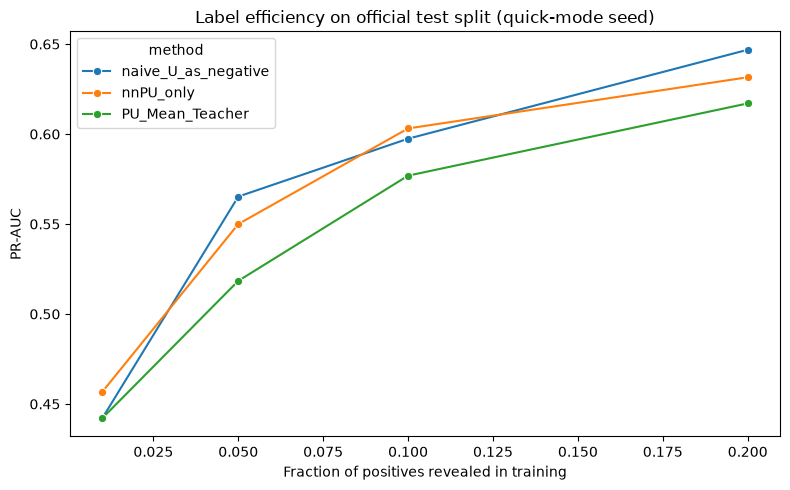

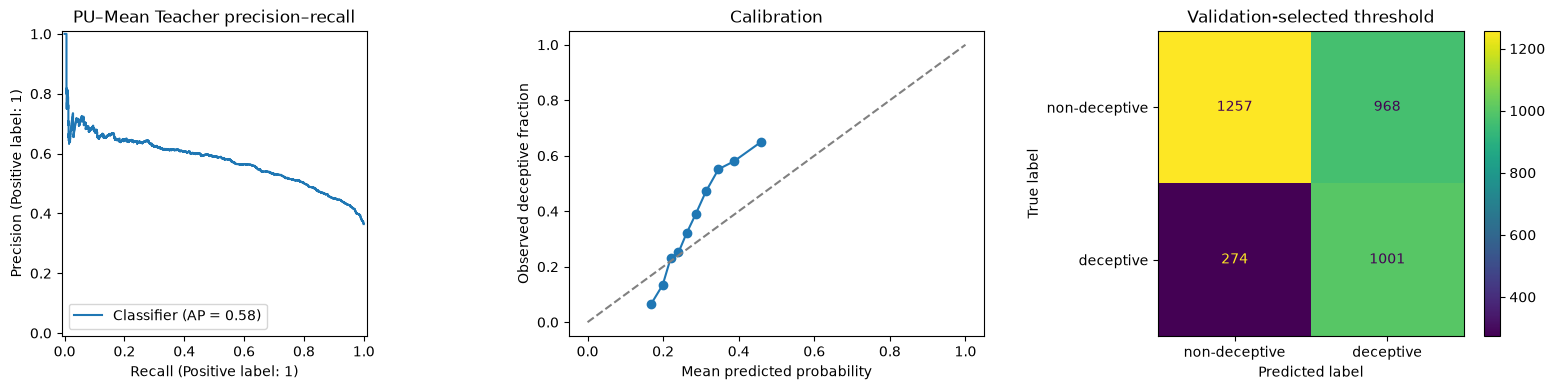

Test F1 bootstrap percentile 95% CI: [0.59508016 0.63589571]


In [12]:
plot=results[results.method.isin(["naive_U_as_negative","nnPU_only","PU_Mean_Teacher"])]
plt.figure(figsize=(8,5));sns.lineplot(data=plot,x="fraction",y="pr_auc",hue="method",marker="o",errorbar=None);plt.title("Label efficiency on official test split (quick-mode seed)");plt.ylabel("PR-AUC");plt.xlabel("Fraction of positives revealed in training");plt.tight_layout();plt.show()

best_frac=.10;part=make_pu_partition(train,best_frac,CONFIG["seed"]);pi=elkan_noto_prior(part)
best_model,_=train_pu_teacher(E["train"],part,pi,CONFIG["seed"],True)
vp=predict_neural(best_model,E["validation"]);tp=predict_neural(best_model,E["test"]);threshold=choose_threshold(val.label,vp)
from sklearn.metrics import PrecisionRecallDisplay
fig,axes=plt.subplots(1,3,figsize=(16,4))
PrecisionRecallDisplay.from_predictions(test.label,tp,ax=axes[0]);axes[0].set_title("PU–Mean Teacher precision–recall")
prob_true,prob_pred=calibration_curve(test.label,tp,n_bins=10,strategy="quantile");axes[1].plot(prob_pred,prob_true,"o-");axes[1].plot([0,1],[0,1],"--",color="gray");axes[1].set(title="Calibration",xlabel="Mean predicted probability",ylabel="Observed deceptive fraction")
ConfusionMatrixDisplay.from_predictions(test.label,tp>=threshold,ax=axes[2],display_labels=["non-deceptive","deceptive"]);axes[2].set_title("Validation-selected threshold")
plt.tight_layout();plt.show()

rng=np.random.default_rng(42);values=[]
for _ in range(500):
    ix=rng.integers(0,len(test),len(test));values.append(f1_score(test.label.iloc[ix],tp[ix]>=threshold,zero_division=0))
print("Test F1 bootstrap percentile 95% CI:",np.quantile(values,[.025,.975]))

## 8. Error analysis and cautious interpretability

In [13]:
errors=test.assign(probability=tp,prediction=(tp>=threshold).astype(int))
errors["error_type"]=np.select([(errors.label==0)&(errors.prediction==1),(errors.label==1)&(errors.prediction==0)],["false_positive","false_negative"],default="correct")
display(errors[errors.error_type!="correct"].groupby(["domain","error_type"]).size().unstack(fill_value=0))
errors["length_bin"]=pd.qcut(errors.char_count.rank(method="first"),4,labels=["short","medium-short","medium-long","long"])
display(errors.assign(error=errors.error_type.ne("correct")).groupby(["length_bin","domain"],observed=True).error.mean().unstack().round(2))
display(errors.assign(has_url=errors.url_count.gt(0),error=errors.error_type.ne("correct")).groupby(["domain","has_url"]).error.mean().unstack().round(2))
display(errors[errors.error_type!="correct"].assign(confidence=lambda x:abs(x.probability-.5),text=lambda x:x.text.str[:180]).nlargest(12,"confidence")[["domain","error_type","label","probability","text"]])

# Classical coefficients are directional associations, not causal explanations.
lr=text_model.named_steps["logisticregression"];vec=text_model.named_steps["tfidfvectorizer"];names=vec.get_feature_names_out();coef=lr.coef_[0]
display(pd.DataFrame({"toward_deceptive":names[np.argsort(coef)[-15:][::-1]],"coefficient":np.sort(coef)[-15:][::-1]}))
display(pd.DataFrame({"toward_non_deceptive":names[np.argsort(coef)[:15]],"coefficient":np.sort(coef)[:15]}))
print("Inspect these for URL artifacts, political names, review/job templates, source vocabulary, and formatting shortcuts; coefficients do not prove semantic importance.")

error_type,false_negative,false_positive
domain,,
fake_news,81,128
job_scams,12,90
phishing,10,125
political_statements,52,163
product_reviews,12,233
sms,12,145
twitter_rumours,95,84


domain,fake_news,job_scams,phishing,political_statements,product_reviews,sms,twitter_rumours
length_bin,,,,,,,
short,NaN,0.00,0.22,0.45,0.44,0.33,0.33
medium-short,1.00,0.25,0.43,0.39,0.52,0.25,0.37
medium-long,0.53,0.26,0.27,0.47,0.45,0.50,NaN
long,0.39,0.14,0.26,NaN,0.73,NaN,NaN


has_url,False,True
domain,,
fake_news,0.42,0.33
job_scams,0.20,NaN
phishing,0.27,0.25
political_statements,0.43,NaN
product_reviews,0.49,0.00
sms,0.32,0.09
twitter_rumours,0.30,0.39


,domain,error_type,label,probability,text
323,phishing,false_negative,1,0.138863,"hi and?, ... ? .., to from ? ,today from !! ou..."
798,fake_news,false_negative,1,0.147971,Supporters of the rule of law crashed a pro-il...
742,fake_news,false_negative,1,0.160067,This is what having no freedom of speech looks...
3277,twitter_rumours,false_negative,1,0.160360,"Hearing about the hostage situation in Sydney,..."
755,fake_news,false_negative,1,0.163170,Donald Trump s White House has been going thro...
3371,twitter_rumours,false_negative,1,0.163180,Rest In Peace Corporal Nathan Cirillo. #Respe...
799,fake_news,false_negative,1,0.164054,Members of the House Intelligence Committee ar...
3266,twitter_rumours,false_negative,1,0.166024,BREAKING NEWS: Killed Charlie Hebdo suspects c...
883,fake_news,false_negative,1,0.167560,Here's Pence getting booed as he gets to his s...
415,phishing,false_negative,1,0.171068,Jose Rewards for Christmas -------------------...


,toward_deceptive,coefficient
0,this,2.451274
1,account,2.337931
2,obama,2.006663
3,the,1.924533
4,your,1.856570
5,breaking,1.674630
6,your account,1.641662
7,has,1.517613
8,hostage,1.453904
9,txt,1.318836


,toward_non_deceptive,coefficient
0,said,-1.922487
1,ok,-1.789849
2,ferguson,-1.725964
3,charliehebdo,-1.597365
4,team,-1.435666
5,jesuischarlie,-1.282629
6,work,-1.251706
7,are you,-1.242341
8,ferguson http,-1.213330
9,looking for,-1.199456


Inspect these for URL artifacts, political names, review/job templates, source vocabulary, and formatting shortcuts; coefficients do not prove semantic importance.


## 9. Conclusions, limitations, and execution manifest

Interpret the tables above, not anticipated outcomes. Compare `nnPU_only` with `naive_U_as_negative`, and `PU_Mean_Teacher` with `nnPU_only`, at matched fractions. One quick-mode seed cannot support significance claims; standard deviations are undefined and the bootstrap interval quantifies sampling—not training—uncertainty. Full mode supplies three paired seeds and seven LODO rotations; a paired permutation or Wilcoxon test is appropriate only after those runs exist.

Major limitations include simulated rather than naturally occurring PU selection; uncertain and domain-varying positive priors; source provenance, duplicates, and shallow artifacts; English-only heterogeneous constituent data; capped quick-mode samples; and limited hyperparameter search. Deception is not factual falsity, and attribution is not intent. False positives have real costs. No autonomous enforcement is justified.

Future work should de-duplicate before training, estimate domain-conditional priors, run all seeds and LODO domains, fine-tune a compact transformer on GPU, add nested validation for augmentation/threshold choices, audit subgroups and temporal drift, trace every constituent dataset license/provenance record, and externally validate on post-collection domains.

In [14]:
EXECUTION_MANIFEST = pd.DataFrame([
 {"experiment":"Official seven-domain acquisition and quality audit","executed":True,"scope":f"{MODE}: {len(data)} rows; official SHA {DATASET_REVISION[:12]}"},
 {"experiment":"In-domain baselines and PU fractions","executed":True,"scope":f"fractions={CONFIG['positive_fractions']}, seeds={CONFIG['seeds']}"},
 {"experiment":"PU–Mean Teacher and ablations","executed":True,"scope":"frozen MiniLM embeddings; validation early stopping"},
 {"experiment":"LODO","executed":True,"scope":str(CONFIG["lodo_domains"])},
 {"experiment":"Full transformer fine-tuning","executed":False,"scope":"configuration/design only; GPU required"},
 {"experiment":"Full three-seed/all-domain experiment","executed":MODE=="full","scope":"not represented by quick-mode outputs"},
])
display(EXECUTION_MANIFEST)
print("No test labels were used for fitting, prior estimation, early stopping, calibration, or threshold selection.")

,experiment,executed,scope
0,Official seven-domain acquisition and quality ...,True,quick: 10500 rows; official SHA aaaf94b336c5
1,In-domain baselines and PU fractions,True,"fractions=[0.01, 0.05, 0.1, 0.2], seeds=[42]"
2,PU–Mean Teacher and ablations,True,frozen MiniLM embeddings; validation early sto...
3,LODO,True,"['job_scams', 'product_reviews', 'phishing']"
4,Full transformer fine-tuning,False,configuration/design only; GPU required
5,Full three-seed/all-domain experiment,False,not represented by quick-mode outputs


No test labels were used for fitting, prior estimation, early stopping, calibration, or threshold selection.
